<h4 style="color: pink";><strong>PRÁCTICA 3 </strong></h3> Análisis Estadistico de Señales </h4>
<p>Karen Agudelo Toro, c.c. 1036250737</p>
<p>Luisa María Herández, c.c.</p>

<h4 style="color: white;"><h3><strong>RESUMEN</strong></h3>

Falta hacer resumen

In [1]:
import numpy as np 
import pandas as pd
import statistics as st
from scipy.io import loadmat 
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy import stats as st
from statsmodels.tsa.stattools import adfuller


<h4><strong>Implementación de funciones</strong></h4>

In [3]:
def RMS(señal):
    N = len(señal)
    suma = 0
    for i in range(N):
        suma += señal[i]**2
    resultado = np.sqrt(suma/N)
    return resultado

<h4><strong>Análisis estadístico de ECG</strong></h4>

Cargamos el archivo

In [4]:
data = loadmat('signals.mat')

Para entender como está organizado el .mat, imprimimos las llaves en consola.

In [5]:
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


Se extraen las columnas de interés y se convierte el vector 1D con el metodo flatten()

In [6]:
ECG_recording = data['ECG_asRecording'].flatten()
ECG_filtered = data['ECG_filtered'].flatten()

<h4><strong>1)</strong></h4>

Para crear el vector de tiempo: tenemos en cuenta el numero de muestras (N), la frecuencia de muestreo dada, el periodo de muestreo y el tiempo de duración de las señales que corresponde a: N muestras / fs muestras = s

In [7]:
N = len(ECG_recording)
fs = 1024
Tm = 1/fs
Tf = N/fs #tiempo de duración de las señales
t = np.arange(0,Tf,Tm)
print(len(t),N)

30720 30720


<h4><strong>2)</strong></h4>
<p><strong>Grafica señal filtrada vs señal original</strong></p>

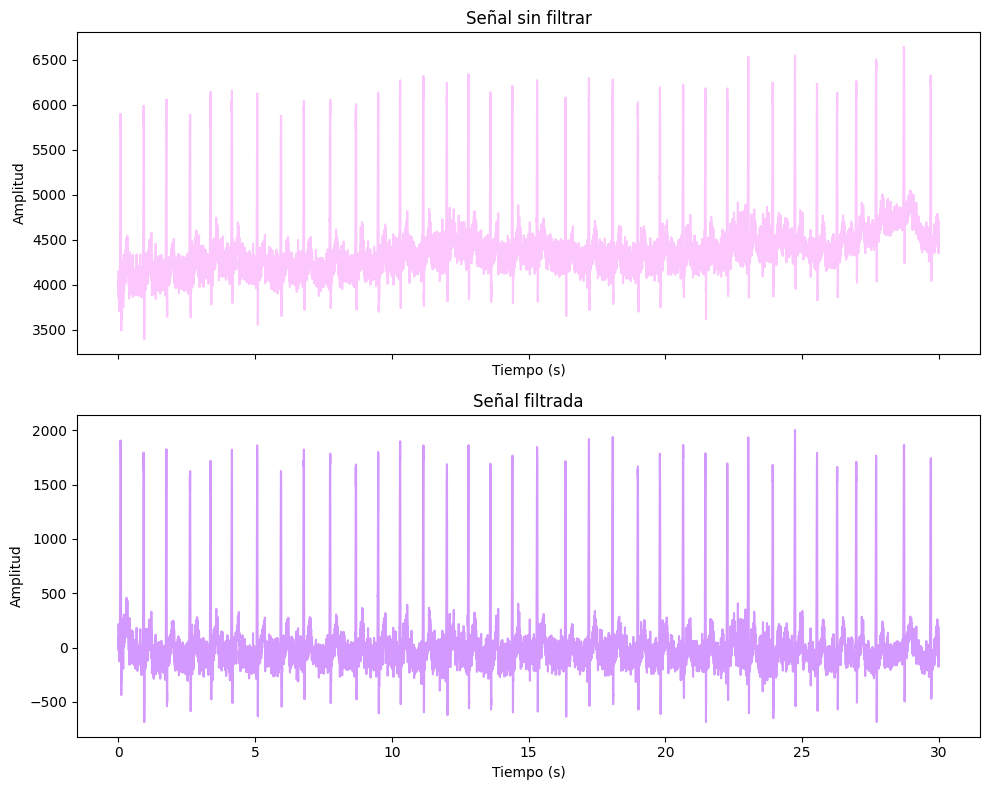

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

#Señal sin filtrar
ax1.plot(t,ECG_recording, color ='#FBC7FC')
ax1.set_title('Señal sin filtrar')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Amplitud')

ax2.plot(t, ECG_filtered, color= '#D399FF')
ax2.set_title('Señal filtrada')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Amplitud')

plt.tight_layout()
plt.show()


<p>Los modernos equipos de ECG registran la señal de ECG en la banda de paso de 0,05 (o 0,5) Hz a 100 (o 150) Hz como estándar de la industria. [1]
Entonces si se desean conservar las frecuencias por encima de 0,05 y por debajo de 150, se debe eliminar lo que está por debajo de 0,05 y lo que está por encima de 150 Hz. Y esto se logra con un filtro pasa . </p>

<h4><strong>Calculo estadísticas señal original</strong><h4>

<h4><strong>3)</strong></h4>
<p><strong>Selección de un ciclo cardiaco</strong></p>

<p>
Para graficar un solo ciclo cardíaco, debemos encontrar los picos R de la señal. 
Para ello se utiliza la función find_peaks  de scipy.signal:
</p>

peaks, _ = find_peaks(señal, height, distance) [2]

<p>Los parámetros se definen así:</p>


<strong>height:</strong> altura mínima para considerar un pico. Mirando la gráfica, los picos R de la señal sin filtrar llegan a ~6000-6500 y la línea base está alrededor de ~4000-4500, por lo tanto se establece height=5500, por encima de la línea base pero por debajo de los picos R.
<strong>distance:</strong> distancia mínima entre picos en muestras. Suponiendo el caso extremo de 200 bpm:
-Tiempo entre latidos: t = 60s / 200 bpm = 0.3 s
-En muestras: 0.3 × 1024 = 307 muestras → distance=307

In [9]:
peaks, _ = find_peaks(ECG_recording, height=5500, distance=307)

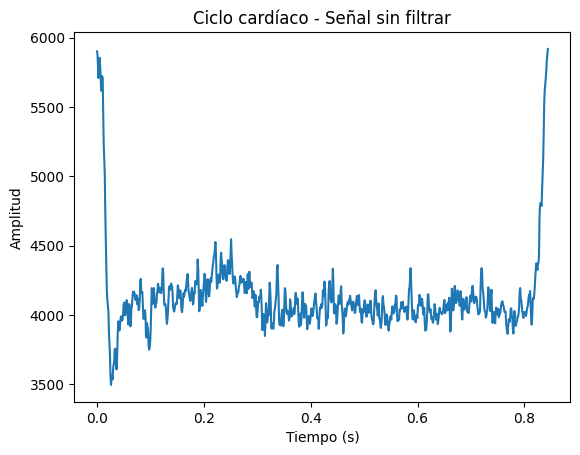

In [10]:
ciclo_r = ECG_recording[peaks[0]:peaks[1]]
t_ciclo = np.arange(0, len(ciclo_r)/fs, 1/fs)

plt.plot(t_ciclo, ciclo_r)
plt.title('Ciclo cardíaco - Señal sin filtrar')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

In [11]:
def estad(señal,nombre):
    promedio = np.mean(señal)
    rms = RMS(señal)
    varianza = np.var(señal)
    std = np.std(señal)

    print(f"===== Estadísticos {nombre} =====")
    print(f"Promedio: {promedio:.4f}")
    print(f"RMS: {rms:.4f}")
    print(f"Varianza: {varianza:.4f}")
    print(f"Desviación estándar: {std:.4f}")

In [12]:
estad(ciclo_r,'señal original')

===== Estadísticos señal original =====
Promedio: 4131.1363
RMS: 4142.4550
Varianza: 93646.2221
Desviación estándar: 306.0167


<p><strong>4)Selección de un ciclo cardiaco señal filtrada</strong></p>

Para la señal filtrada, repetimos los mismos pasos

In [13]:
peaks, _ = find_peaks(ECG_filtered, height=500, distance=307)

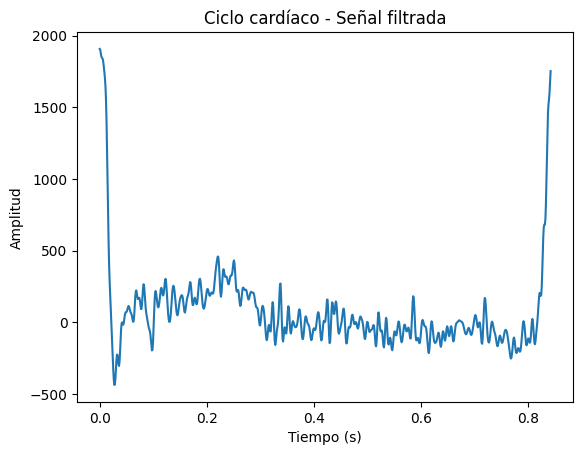

In [14]:
ciclo_f = ECG_filtered[peaks[0]:peaks[1]]
t_ciclo = np.arange(0, len(ciclo_f)/fs, 1/fs)

plt.plot(t_ciclo, ciclo_f)
plt.title('Ciclo cardíaco - Señal filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

In [15]:
estad(ciclo_f,'señal filtrada')

===== Estadísticos señal filtrada =====
Promedio: 74.0100
RMS: 319.6276
Varianza: 96684.3149
Desviación estándar: 310.9410


Al comparar los estadísticos de ambas señales, se observa que el **promedio** pasa de ~4131 en la señal original a ~74 en la filtrada, lo cual indica que el filtro eliminó la componente DC  presente en la señal sin procesar. De manera similar, el **RMS** disminuye significativamente de ~4142 a ~320, ya que en la señal original este valor está dominado por el offset y no refleja la "energía" real de la señal ECG.

Por otro lado, la **varianza** y la **desviación estándar** presentan valores similares en ambas señales (~93646 vs ~96684 y ~306 vs ~311 respectivamente). Esto se debe a que estas medidas calculan la dispersión **alrededor de la media**, por lo que no se ven afectadas por el offset DC.

<p><strong>5)ciclos señal filtrada</strong></p>

In [16]:
def ciclos_sf(señal,peaks):
    fs = 1024
    estadisticos = []
    fig, axes = plt.subplots(3, 5, figsize=(15, 8))
    axes = axes.flatten() 

    for i in range(15):
        ciclo = señal[peaks[i]:peaks[i+1]]
        t_ciclo = np.arange(0, len(ciclo)/fs, 1/fs)
        promedio = np.mean(ciclo)
        varianza = np.var(ciclo)
        estadisticos.append({'ciclo': i+1, 'promedio': promedio, 'varianza': varianza})

        axes[i].plot(t_ciclo, ciclo)
        axes[i].set_title(f'Ciclo {i+1}')
        axes[i].set_xlabel('Tiempo (s)')
        axes[i].set_ylabel('Amplitud')

    plt.tight_layout() 
    plt.show()
    return estadisticos


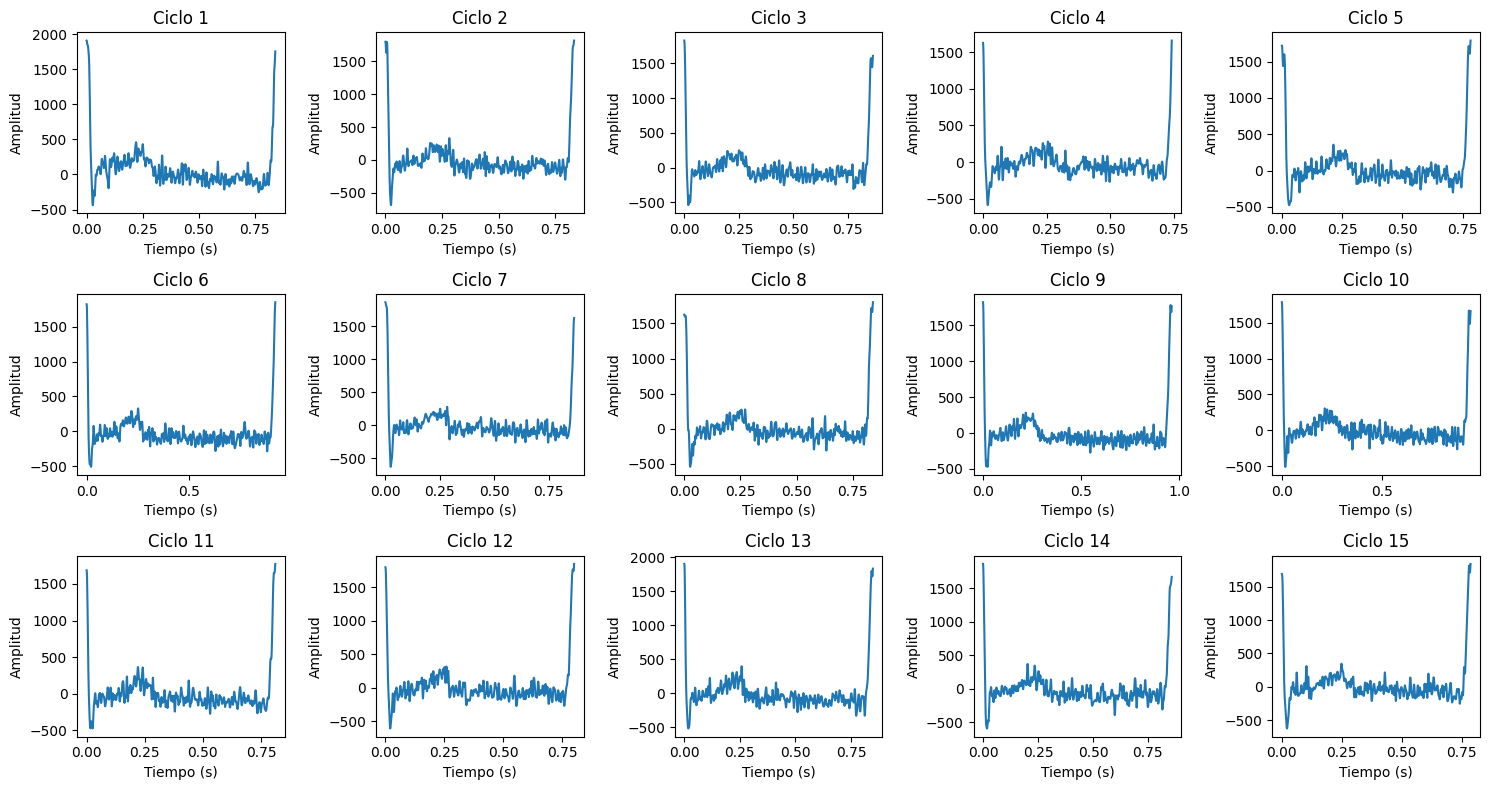

    ciclo   promedio       varianza
0       1  74.009958   96684.314882
1       2  -1.462578  104790.465489
2       3 -10.433000   82451.251079
3       4 -20.975178   46839.019694
4       5  40.871105  114850.020065
5       6 -27.943734   58147.589512
6       7   0.430787   77707.281202
7       8  21.407853  100268.181528
8       9 -10.175290   71784.955786
9      10   8.812103   68481.059763
10     11  -8.906158   76088.384898
11     12  13.213274   93862.695883
12     13  -4.203263   87951.504476
13     14 -14.969689   77022.132917
14     15  27.108316   89636.935600


In [17]:
resultados = ciclos_sf(ECG_filtered, peaks)
df = pd.DataFrame(resultados)
print(df)

Al extraer 15 ciclos cardíacos de la señal ECG filtrada y analizar sus estadísticos, se observa que el promedio varía entre aproximadamente -28 y 74, y la varianza entre ~46839 y ~114850. Aunque los valores del promedio rondan el cero (lo cual es esperado dado que el filtro eliminó el offset DC), la variación entre ciclos es considerable. La varianza presenta cambios importantes de un ciclo a otro, lo que indica que la dispersión de la señal no es constante en el tiempo.
Visualmente, si bien la forma general de los ciclos es similar y los picos R se mantienen en un rango de amplitud de 1400-2000, se pueden apreciar diferencias en la morfología y amplitud entre algunos ciclos.
Con base en el análisis gráfico y estadístico, no se puede considerar que la señal ECG sea estacionaria, ya que sus características estadísticas (especialmente la varianza) no se mantienen constantes a lo largo del tiempo. Esto es consistente con la naturaleza de las bioseñales, las cuales están sujetas a variaciones fisiológicas y artefactos que alteran sus propiedades estadísticas.

<p><strong>6) Comparación de ciclos y prueba t</strong></p>

Se elige la comparación entre el ciclo 2 y 10. 

Teniendo en cuenta que los supuestos se verifican en este orden:
Normalidad → prueba de Shapiro-Wilk
Independencia → se asume (los ciclos son independientes entre sí)
Homocedasticidad → prueba de Levene

In [18]:
def test_normalitySW(data, variable):
    print(f"\nAnálisis de normalidad por Shapiro-Wilk para '{variable}'")
    shapiro_stat, shapiro_p = st.shapiro(data)
    print(f"Estadístico = {shapiro_stat:.4f}, p-valor = {shapiro_p:.4f}")
    
    if shapiro_p > 0.05:
        print(f"Los datos siguen una distribución normal (p > 0.05)")
    else:
        print(f"Los datos NO siguen una distribución normal (p ≤ 0.05)")
    
    return shapiro_stat, shapiro_p

In [19]:
def test_levene(data1, data2, variable1, variable2):
    
    print(f"\nPrueba de Levene entre '{variable1}' y '{variable2}'")
    levene_stat, levene_p = st.levene(data1, data2)
    print(f"Estadístico = {levene_stat:.4f}, p-valor = {levene_p:.4f}")
    
    if levene_p > 0.05:
        print(f"→ Las varianzas son iguales, se asume homocedasticidad (p > 0.05)")
    else:
        print(f"→ Las varianzas NO son iguales, no hay homocedasticidad (p ≤ 0.05)")
    
    return levene_stat, levene_p

In [20]:
def test_levene(data1, data2, variable1, variable2):
    print(f"\nPrueba de Levene entre '{variable1}' y '{variable2}'")
    levene_stat, levene_p = st.levene(data1, data2)
    print(f"Estadístico = {levene_stat:.4f}, p-valor = {levene_p:.4f}")
    
    if levene_p > 0.05:
        print(f"Las varianzas son iguales, se asume homocedasticidad (p > 0.05)")
    else:
        print(f"Las varianzas NO son iguales, no hay homocedasticidad (p ≤ 0.05)")
    
    return levene_stat, levene_p

In [21]:
def test_t(data1, data2, variable1, variable2, equal_var=True):
    """
    equal_var: True si Levene indicó homocedasticidad, False si no
    """
    print(f"\nPrueba t entre '{variable1}' y '{variable2}'")
    t_stat, t_p = st.ttest_ind(data1, data2, equal_var=equal_var)
    print(f"Estadístico = {t_stat:.4f}, p-valor = {t_p:.4f}")
    
    if t_p > 0.05:
        print(f" No hay diferencia estadística entre los ciclos (p > 0.05)")
    else:
        print(f"Existe diferencia estadística entre los ciclos (p ≤ 0.05)")
    
    return t_stat, t_p

In [30]:
ciclo_a = ECG_filtered[peaks[1]:peaks[2]]  # Ciclo 2
ciclo_b = ECG_filtered[peaks[9]:peaks[10]] # Ciclo 10

In [28]:
_, shapiro_p1 = test_normalitySW(ciclo_a, "Ciclo 2")
_, shapiro_p2 = test_normalitySW(ciclo_b, "Ciclo 10")

_, levene_p = test_levene(ciclo_a, ciclo_b, "Ciclo 2", "Ciclo 10")

if shapiro_p1 > 0.05 and shapiro_p2 > 0.05:
    test_t(ciclo_a, ciclo_b, "Ciclo 2", "Ciclo 10", equal_var=(levene_p > 0.05))
else:
    print("\nNo se cumple normalidad → Se aplica prueba U de Mann-Whitney")
    stat, p = st.mannwhitneyu(ciclo_a, ciclo_b)
    print(f"Estadístico = {stat:.4f}, p-valor = {p:.4f}")


Análisis de normalidad por Shapiro-Wilk para 'Ciclo 2'
Estadístico = 0.5503, p-valor = 0.0000
Los datos NO siguen una distribución normal (p ≤ 0.05)

Análisis de normalidad por Shapiro-Wilk para 'Ciclo 10'
Estadístico = 0.5570, p-valor = 0.0000
Los datos NO siguen una distribución normal (p ≤ 0.05)

Prueba de Levene entre 'Ciclo 2' y 'Ciclo 10'
Estadístico = 3.4882, p-valor = 0.0620
Las varianzas son iguales, se asume homocedasticidad (p > 0.05)

No se cumple normalidad → Se aplica prueba U de Mann-Whitney
Estadístico = 356131.0000, p-valor = 0.0000


Análisis resultados estadisticos 

**Shapiro-Wilk:** ambos ciclos tienen p = 0.0000 → **no se cumple normalidad**, por lo tanto no se puede aplicar la prueba t directamente.

**Levene:** p = 0.0620 > 0.05 → **hay homocedasticidad**, las varianzas son iguales. Pero como no se cumple normalidad, este resultado no es suficiente para usar la prueba t.

**Mann-Whitney:** p = 0.0000 < 0.05 → **existe diferencia estadística significativa entre los ciclos 2 y 10.**

In [32]:
ciclo_c = ECG_filtered[peaks[3]:peaks[4]]   # Ciclo 4
ciclo_d = ECG_filtered[peaks[12]:peaks[13]] # Ciclo 13

_, shapiro_p1 = test_normalitySW(ciclo_c, "Ciclo 4")
_, shapiro_p2 = test_normalitySW(ciclo_d, "Ciclo 13")

_, levene_p = test_levene(ciclo_c, ciclo_d, "Ciclo 4", "Ciclo 13")

if shapiro_p1 > 0.05 and shapiro_p2 > 0.05:
    test_t(ciclo_c, ciclo_d, "Ciclo 4", "Ciclo 13", equal_var=(levene_p > 0.05))
else:
    print("\nNo se cumple normalidad -->Se aplica prueba U de Mann-Whitney")
    stat, p = st.mannwhitneyu(ciclo_c, ciclo_d)
    print(f"Estadístico = {stat:.4f}, p-valor = {p:.4f}")


Análisis de normalidad por Shapiro-Wilk para 'Ciclo 4'
Estadístico = 0.6607, p-valor = 0.0000
Los datos NO siguen una distribución normal (p ≤ 0.05)

Análisis de normalidad por Shapiro-Wilk para 'Ciclo 13'
Estadístico = 0.5462, p-valor = 0.0000
Los datos NO siguen una distribución normal (p ≤ 0.05)

Prueba de Levene entre 'Ciclo 4' y 'Ciclo 13'
Estadístico = 3.2356, p-valor = 0.0722
Las varianzas son iguales, se asume homocedasticidad (p > 0.05)

No se cumple normalidad -->Se aplica prueba U de Mann-Whitney
Estadístico = 342113.0000, p-valor = 0.2430


Shapiro-Wilk: ambos ciclos p = 0.0000 no se cumple normalidad, igual que antes.
Levene: p = 0.0722 > 0.05 → hay homocedasticidad, igual que antes.
Mann-Whitney: p = 0.2430 > 0.05: NO existe diferencia estadística entre los ciclos 4 y 13.
Esto es muy interesante para el análisis de estacionariedad:

Comparación 1 (Ciclo 2 vs 10): sí hay diferencia, lo que sugiere no estacionariedad
Comparación 2 (Ciclo 4 vs 13): no hay diferencia, lo que sugiere que algunos ciclos son estadísticamente similares

Esto refuerza la conclusión de que la señal no es completamente estacionaria, ya que algunos pares de ciclos muestran diferencias estadísticas significativas mientras otros no.

<p><strong>7) Prueba Dickey- Fuller</strong></p>

In [34]:
result = adfuller(np.squeeze(ECG_filtered))
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -33.135995
p-value: 0.000000


- **ADF Statistic: -33.13** tiene valor muy negativo, lo cual es una señal fuerte
- **p-value: 0.000000** < 0.05, entonces **se rechaza H0**

Esto indica que la señal ECG filtrada **es estacionaria** según Dickey-Fuller.
Sin embargo, parece contradictorio con la conclusión con los ciclos. Pero, Dickey-Fuller evalúa la estacionariedad de la señal **completa** en términos de raíz unitaria (si la señal tiene una tendencia que crece o decrece indefinidamente). La señal ECG filtrada no tiene esa tendencia, por eso Dickey-Fuller la considera estacionaria.

Sin embargo, al analizar ciclo a ciclo se observa que la **varianza y el promedio cambian** entre ciclos, lo que indica **no estacionariedad en sentido estricto**.

Entonces:
> *La prueba de Dickey-Fuller indica estacionariedad en términos de raíz unitaria (p < 0.05). Sin embargo, el análisis por ciclos mostró variaciones en el promedio y la varianza, sugiriendo que la señal no es estrictamente estacionaria. Esto es consistente con la naturaleza de las bioseñales.*

### Comparacion estadistica de energía de señales  EEG 

Inspección inicia de clave de datos, y dimension de datos 

In [2]:
dataL = loadmat('control/C001R_EP_reposo.mat')
print(dataL.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data'])


In [3]:
EEGC=dataL['data']
print("Dimensiones (Shape):", EEGC.shape)

Dimensiones (Shape): (8, 2000, 180)


Se identifica organizacion de matriz de datos en  (canales, muestras, épocas)

In [4]:
import os
def cargar_datos_mat(ruta_carpeta):
    """
    Carga todos los archivos .mat de una carpeta y extrae la clave 'data'.
    Retorna una lista con las matrices de señales.
    """

    archivos_mat = sorted([f for f in os.listdir(ruta_carpeta) if f.endswith('.mat')]) #obtener archivos y organizacion por nombres 
    lista_eeg = [] #lista de alamacenamiento 
    
    # 2. Bucle de carga
    for narchivo in archivos_mat:
        ruta = os.path.join(ruta_carpeta, narchivo)
        data_temp = loadmat(ruta)
        if 'data' in data_temp: #clave segun inspeccion 
            lista_eeg.append(data_temp['data'])
    print(f"Carpeta '{ruta_carpeta}': {len(lista_eeg)} archivos cargados con éxito.")
    return lista_eeg

#extraccion de datos en listas 
eeg_control = cargar_datos_mat('control/') #lista de archivos de control
eeg_parkinson = cargar_datos_mat('parkinson')# lista de archivos de parkinson 


Carpeta 'control/': 36 archivos cargados con éxito.
Carpeta 'parkinson': 23 archivos cargados con éxito.




$$E = \sum_{n=1}^{N} |x[n]|^2$$

Se calcual la energía de cada epoca usando la anterior sumatoria

Una vez se tiene la energía de todas las épocas de un canal se calcula el promedio 

In [6]:

def calcular_energia_promedio_sujeto(senal):
    """
    PUNTO 1: Recibe una señal de (canales, muestras, épocas)
    Calcula la energía promedio de cada canal.
    """
    # 1. Elevamos al cuadrado: |x[n]|^2
    cuadrado = np.square(senal)
    
    # 2. Sumamos en el eje de las muestras (Eje 1) para obtener la energía por época
    energia_por_epoca = np.sum(cuadrado, axis=1)
    
    # 3. Promediamos en el eje de las épocas (Eje 1) para obtener un valor por canal
    energia_promedio_canal = np.mean(energia_por_epoca, axis=1)
    
    return energia_promedio_canal


In [10]:
# --- PROCESAMIENTO GRUPO CONTROL ---
energias_control = []
for sujeto in eeg_control:
    res = calcular_energia_promedio_sujeto(sujeto)
    energias_control.append(res)

# Crear DataFrame para Control
columnas_canales = [f'Canal_{i+1}' for i in range(8)]
df_control = pd.DataFrame(energias_control, columns=columnas_canales)
df_control.index.name = '#sujeto'


# --- PROCESAMIENTO GRUPO PARKINSON ---
energias_parkinson = []
for sujeto in eeg_parkinson:
    res = calcular_energia_promedio_sujeto(sujeto)
    energias_parkinson.append(res)

# Crear DataFrame para Parkinson
df_parkinson = pd.DataFrame(energias_parkinson, columns=columnas_canales)
df_parkinson.index.name = '#sujeto'



In [11]:
from tabulate import tabulate

# --- INSPECCIÓN DE TODOS LOS RESULTADOS ---

print("\n" + "="*30)
print("DATOS DE ENERGÍA: GRUPO CONTROL")
print("="*30)
# Al quitar el .head(), tabulate procesará todas las filas (las 36 de control)
print(tabulate(df_control, headers='keys', tablefmt='github', showindex=True))

print("\n" + "="*30)
print("DATOS DE ENERGÍA: GRUPO PARKINSON")
print("="*30)
# Aquí procesará las 23 filas de Parkinson
print(tabulate(df_parkinson, headers='keys', tablefmt='github', showindex=True))


DATOS DE ENERGÍA: GRUPO CONTROL
|   #sujeto |   Canal_1 |   Canal_2 |   Canal_3 |   Canal_4 |   Canal_5 |   Canal_6 |   Canal_7 |   Canal_8 |
|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|-----------|
|         0 |  21465.7  |  20985.9  |  22760.1  |  18505.6  |  29730.2  |   25244.2 |   22781.3 |   24658.6 |
|         1 |  15966.4  |  17617.8  |  20804.9  |  19654.4  |  16679    |   93894   |   66862.5 |   75685.1 |
|         2 |  14148.7  |  18284    |  28749.9  |  14270.7  |  28787.4  |   14661.4 |   15940.2 |   19499.9 |
|         3 |  35311.3  |  34916.7  |  38800.4  |  35427    |  35905.5  |  106598   |  106886   |  112521   |
|         4 |  18510.8  |  19738.5  |  20911.8  |  21828.3  |  23352    |   53086.1 |   37496   |   43067.1 |
|         5 |  13180.1  |  13925.2  |  16219    |  12324.9  |  14060.3  |   25767   |   21935.8 |   22827.8 |
|         6 |  11197.6  |  10948.4  |  12737    |  10745.2  |  10329.6  |   21461.6 |  

<h4><strong>Referencias</strong></h4>
[1] L. G. Tereshchenko y M. E. Josephson, «Frequency content and characteristics of ventricular conduction», Journal Of Electrocardiology, vol. 48, n.o 6, pp. 933-937, ago. 2015, doi: 10.1016/j.jelectrocard.2015.08.034.

[2] Ninad, «Peak Detection in Signals with scipy.signal.find_peaks - AskPython», AskPython, 19 de noviembre de 2025. https://www.askpython.com/python-modules/scipy/scipy-signal-find-peaks